In [1]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:

# Cargar el dataset principal de solicitudes de adelanto en efectivo
cash_request = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/extract - cash request - data analyst.csv')


In [4]:
cr = cash_request.copy()


In [5]:
# Filtrar columnas relevantes para el análisis
cr = cr[["amount", "created_at", "user_id", "deleted_account_id", "transfer_type"]]
cr.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amount              23970 non-null  float64
 1   created_at          23970 non-null  object 
 2   user_id             21867 non-null  float64
 3   deleted_account_id  2104 non-null   float64
 4   transfer_type       23970 non-null  object 
dtypes: float64(3), object(2)
memory usage: 936.5+ KB


In [6]:
# Rellenar valores nulos en 'user_id' usando 'deleted_account_id'
# (clientes transferidos de cuentas eliminadas)
cr.fillna({"user_id": cr["deleted_account_id"]}, inplace=True)


In [7]:
# Eliminar la columna 'deleted_account_id' ya que no es necesaria después de la imputación
cr.drop(columns=["deleted_account_id"], inplace=True)
cr.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   amount         23970 non-null  float64
 1   created_at     23970 non-null  object 
 2   user_id        23970 non-null  float64
 3   transfer_type  23970 non-null  object 
dtypes: float64(2), object(2)
memory usage: 749.2+ KB


In [8]:
# Convertir 'created_at' a tipo datetime para manipulación de fechas
cr['created_at'] = pd.to_datetime(cr['created_at'])
cr.head()


,amount,created_at,user_id,transfer_type
0,100.0,2019-12-10 19:05:21.596873+00:00,804.0,regular
1,100.0,2019-12-10 19:50:12.347780+00:00,231.0,regular
2,100.0,2019-12-10 19:13:35.825460+00:00,191.0,regular
3,99.0,2019-12-10 19:16:10.880172+00:00,761.0,regular
4,100.0,2020-05-06 09:59:38.877376+00:00,7686.0,regular


In [9]:
# Convertir la columna 'created_at' a una fecha sin zona horaria
cr['created_at'] = cr['created_at'].dt.tz_localize(None)
cr.head()


,amount,created_at,user_id,transfer_type
0,100.0,2019-12-10 19:05:21.596873,804.0,regular
1,100.0,2019-12-10 19:50:12.347780,231.0,regular
2,100.0,2019-12-10 19:13:35.825460,191.0,regular
3,99.0,2019-12-10 19:16:10.880172,761.0,regular
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular


In [10]:
# Crear columna 'Mes' indicando el mes de cada solicitud
cr['Mes'] = cr['created_at'].dt.to_period('M')
cr.head()


,amount,created_at,user_id,transfer_type,Mes
0,100.0,2019-12-10 19:05:21.596873,804.0,regular,2019-12
1,100.0,2019-12-10 19:50:12.347780,231.0,regular,2019-12
2,100.0,2019-12-10 19:13:35.825460,191.0,regular,2019-12
3,99.0,2019-12-10 19:16:10.880172,761.0,regular,2019-12
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular,2020-05


In [11]:
# Crear columna 'Cohorte' que indica el mes de la primera solicitud de cada cliente
cr['Cohorte'] = cr.groupby('user_id')['created_at'].transform('min').dt.to_period('M')
cr.head(10)


,amount,created_at,user_id,transfer_type,Mes,Cohorte
0,100.0,2019-12-10 19:05:21.596873,804.0,regular,2019-12,2019-12
1,100.0,2019-12-10 19:50:12.347780,231.0,regular,2019-12,2019-12
2,100.0,2019-12-10 19:13:35.825460,191.0,regular,2019-12,2019-12
3,99.0,2019-12-10 19:16:10.880172,761.0,regular,2019-12,2019-12
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular,2020-05,2020-05
5,100.0,2020-05-23 20:58:55.129432,9489.0,regular,2020-05,2020-05
6,100.0,2020-06-16 17:07:38.452652,14631.0,regular,2020-06,2020-06
7,100.0,2020-02-10 01:11:53.808270,309.0,regular,2020-02,2020-01
8,100.0,2020-06-28 12:06:33.712840,2499.0,regular,2020-06,2020-06
9,90.0,2019-12-10 19:51:23.911206,897.0,regular,2019-12,2019-12


In [12]:
# Agregar columnas de temporalidad

# Semana y mes de la solicitud
cr['Semana_Mes'] = cr['created_at'].dt.strftime('%U_%B') + '_' + cr['Mes'].dt.strftime('%Y')

# Día y semana de la solicitud
cr['Dia_Semana'] = cr['created_at'].dt.strftime('%A') + '_' + cr['Semana_Mes']

# Hora y día de la solicitud
cr['Hora_Dia'] = cr['created_at'].dt.hour.astype(str) + '_' + cr['Dia_Semana']

cr.head()


,amount,created_at,user_id,transfer_type,Mes,Cohorte,Semana_Mes,Dia_Semana,Hora_Dia
0,100.0,2019-12-10 19:05:21.596873,804.0,regular,2019-12,2019-12,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
1,100.0,2019-12-10 19:50:12.347780,231.0,regular,2019-12,2019-12,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
2,100.0,2019-12-10 19:13:35.825460,191.0,regular,2019-12,2019-12,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
3,99.0,2019-12-10 19:16:10.880172,761.0,regular,2019-12,2019-12,49_December_2019,Tuesday_49_December_2019,19_Tuesday_49_December_2019
4,100.0,2020-05-06 09:59:38.877376,7686.0,regular,2020-05,2020-05,18_May_2020,Wednesday_18_May_2020,9_Wednesday_18_May_2020


In [13]:
# Calcular la cantidad de adelanto de efectivo por cohorte y mes
cohort_revenue = cr.groupby(['Cohorte', 'Mes'])['amount'].sum().reset_index()

# Crear tabla pivote con Cohorte como índice y Mes como columnas
cohort_revenue = cohort_revenue.pivot(index='Cohorte', columns='Mes', values='amount')

cohort_revenue


Mes,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11
Cohorte,,,,,,,,,,,,,
2019-11,1.0,100.0,NaN,NaN,NaN,100.0,10.0,NaN,NaN,10.0,5.0,6.0,NaN
2019-12,NaN,27197.0,10123.0,5881.0,7650.0,7900.0,8175.0,8805.0,6990.0,7790.0,4860.0,6655.0,100.0
2020-01,NaN,NaN,11464.0,2360.0,1660.0,3500.0,3020.0,2770.0,3010.0,2150.0,1970.0,2350.0,100.0
2020-02,NaN,NaN,NaN,8412.0,4740.0,4607.0,4350.0,4235.0,4405.0,4130.0,2555.0,3595.0,NaN
2020-03,NaN,NaN,NaN,NaN,9499.0,4250.0,4540.0,4850.0,4055.0,3390.0,2800.0,2700.0,50.0
2020-04,NaN,NaN,NaN,NaN,NaN,25736.0,14258.0,14320.0,11000.0,9915.0,7685.0,6450.0,NaN
2020-05,NaN,NaN,NaN,NaN,NaN,NaN,44883.0,30143.0,25725.0,21224.0,16350.0,15305.0,350.0
2020-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180903.0,92672.0,84491.0,60025.0,56525.0,400.0
2020-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180330.0,76873.0,49725.0,47313.0,500.0


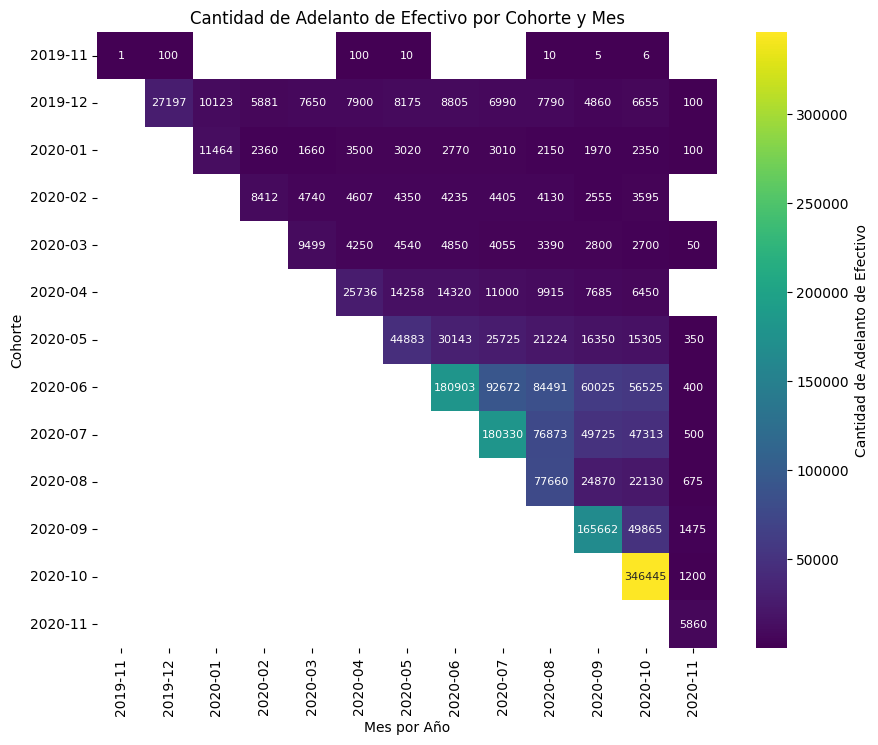

In [14]:
# Graficar la cantidad de adelanto de efectivo por cohorte y mes
plt.figure(figsize=(10, 8))
plt.title('Cantidad de Adelanto de Efectivo por Cohorte y Mes')

sns.heatmap(
    data=cohort_revenue,
    annot=True,
    fmt='.0f',
    cmap='viridis',
    annot_kws={"size": 8},
    cbar_kws={'label': 'Cantidad de Adelanto de Efectivo'}
)

plt.xlabel('Mes por Año')
plt.ylabel('Cohorte')
plt.show()


📊 Resumen estadístico de y_interp:
count     8.000000
mean      9.121885
std       0.467876
min       8.679652
25%       8.920038
50%       8.991851
75%       9.118057
max      10.210899
dtype: float64

📊 Resumen estadístico de y_extrap:
count    3.000000
mean     8.750999
std      0.240168
min      8.488999
25%      8.646137
50%      8.803274
75%      8.881999
max      8.960725
dtype: float64

📈 Correlación entre los últimos 3 puntos de interpolación y primeros 3 de extrapolación:
[[ 1.         -0.48825027]
 [-0.48825027  1.        ]]

📊 Evaluación del Modelo:
RMSE Interpolación: 708.055, RMSE Extrapolación: 2234.443
R² Interpolación: 0.987, R² Extrapolación: -19.435

🔍 Valores negativos en extrapolación:
[]


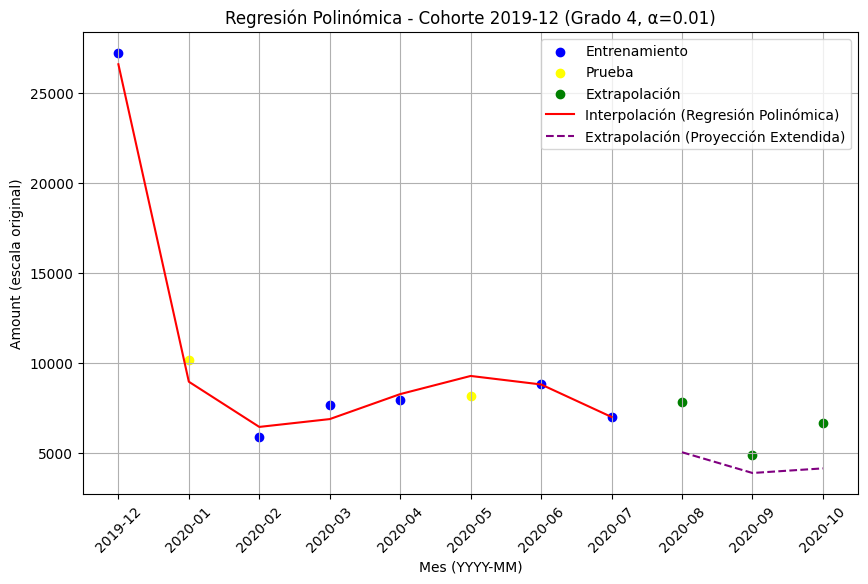

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1️⃣ Aplicar la transformación logarítmica en 'amount'
cohorte_2019_12_log = np.log1p(cohort_revenue.loc['2019-12'].dropna())

# 2️⃣ Convertir índices (Mes) a fechas tipo 'YYYY-MM'
X = pd.to_datetime(cohorte_2019_12_log.index.astype(str), format='%Y-%m')
X_numeric = np.array(range(len(X))).reshape(-1, 1)  # Convertir a índices numéricos para la regresión
y = np.array(cohorte_2019_12_log.values)  # Valores transformados

# 3️⃣ Separar 80% interpolación y 20% extrapolación
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X_numeric[:split_idx], X_numeric[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 4️⃣ Dentro del 80% de interpolación, dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 📊 Evaluación previa: Distribución de datos
print("📊 Resumen estadístico de y_interp:")
print(pd.Series(y_interp).describe())

print("\n📊 Resumen estadístico de y_extrap:")
print(pd.Series(y_extrap).describe())

# 📈 Correlación entre los últimos puntos de interpolación y primeros de extrapolación
print("\n📈 Correlación entre los últimos 3 puntos de interpolación y primeros 3 de extrapolación:")
print(np.corrcoef(y_interp[-3:], y_extrap[:3]))

# 5️⃣ Ajustar modelo de regresión polinómica con Ridge para evitar sobreajuste
degree = 4  # Se puede probar con otros grados
alpha = 0.01  # Regularización

poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_interp_poly = poly.transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# 6️⃣ Entrenar modelo con Ridge
model = Ridge(alpha=alpha)
model.fit(X_train_poly, y_train)

# 7️⃣ Predicciones
y_interp_pred = model.predict(X_interp_poly)  # Predicciones en interpolación
y_extrap_pred = model.predict(X_extrap_poly)  # Predicciones en extrapolación

# 8️⃣ Volver a la escala original (deshacer logaritmo)
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_extrap_orig = np.expm1(y_extrap)

# 9️⃣ Evaluación de modelo: RMSE y R²
rmse_interp = np.sqrt(mean_squared_error(y_interp_pred, np.expm1(y_interp)))
rmse_extrap = np.sqrt(mean_squared_error(y_extrap_pred, y_extrap_orig))
r2_interp = r2_score(y_interp_pred, np.expm1(y_interp))
r2_extrap = r2_score(y_extrap_pred, y_extrap_orig)

print(f"\n📊 Evaluación del Modelo:")
print(f"RMSE Interpolación: {rmse_interp:.3f}, RMSE Extrapolación: {rmse_extrap:.3f}")
print(f"R² Interpolación: {r2_interp:.3f}, R² Extrapolación: {r2_extrap:.3f}")

# 🔍 Ver si hay valores negativos en extrapolación (no deberían existir en Amount)
print("\n🔍 Valores negativos en extrapolación:")
print(y_extrap_pred[y_extrap_pred < 0])

#  🔄 Convertir los valores numéricos de X a etiquetas de fecha
plt.figure(figsize=(10, 6))

# Datos originales transformados de vuelta
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

# Líneas de tendencia
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación (Regresión Polinómica)')
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación (Proyección Extendida)')

# Configuración de la gráfica
plt.xticks(X_numeric.flatten(), X.strftime('%Y-%m'), rotation=45)
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title(f"Regresión Polinómica - Cohorte 2019-12 (Grado {degree}, α={alpha})")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Configurar el Pipeline
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('ridge', Ridge())
])

# Ampliar la búsqueda en cuadrícula
param_grid = {
    'poly__degree': [2, 3, 4, 5, 6],
    'ridge__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

# Validación temporal
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='neg_mean_squared_error')
grid_search.fit(X_interp, y_interp)

print("\n🔍 Mejor combinación de hiperparámetros encontrada:")
print(grid_search.best_params_)



🔍 Mejor combinación de hiperparámetros encontrada:
{'poly__degree': 2, 'ridge__alpha': 10}


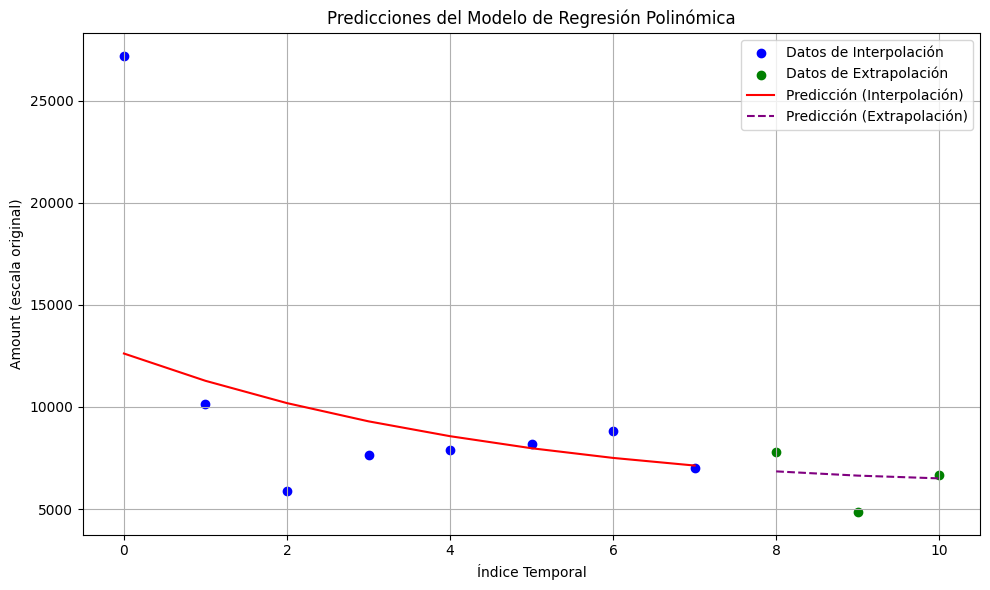

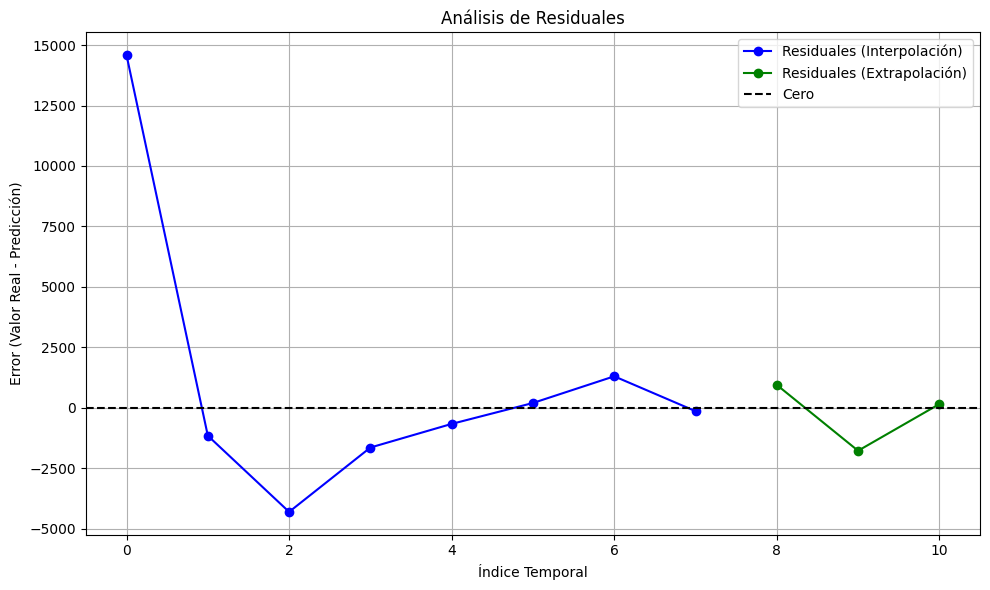

In [37]:
import matplotlib.pyplot as plt

# ───────────────────────────────
# Gráfica 1: Resultados de la Regresión
# ───────────────────────────────

plt.figure(figsize=(10, 6))

# Datos originales en escala original
plt.scatter(X_interp, y_interp_orig, color='blue', label='Datos de Interpolación')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Datos de Extrapolación')

# Líneas de tendencia obtenidas por el modelo
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Predicción (Interpolación)')
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Predicción (Extrapolación)')

# Configuración de la gráfica
plt.xlabel("Índice Temporal")
plt.ylabel("Amount (escala original)")
plt.title("Predicciones del Modelo de Regresión Polinómica")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ───────────────────────────────
# Gráfica 2: Análisis de Residuales
# ───────────────────────────────

# Calcular los residuales: diferencia entre el valor real y la predicción
residuales_interp = y_interp_orig - y_interp_pred
residuales_extrap = y_extrap_orig - y_extrap_pred

plt.figure(figsize=(10, 6))
plt.plot(X_interp, residuales_interp, marker='o', linestyle='-', color='blue', label='Residuales (Interpolación)')
plt.plot(X_extrap, residuales_extrap, marker='o', linestyle='-', color='green', label='Residuales (Extrapolación)')
plt.axhline(0, color='black', linestyle='--', label='Cero')
plt.xlabel("Índice Temporal")
plt.ylabel("Error (Valor Real - Predicción)")
plt.title("Análisis de Residuales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Todas las combinaciones evaluadas:
    param_poly__degree  param_ridge__alpha  mean_test_score  std_test_score  \
4                    1              10.000    -1.353203e-01    1.714566e-01   
17                   3             100.000    -1.881681e-01    1.493200e-01   
10                   2              10.000    -2.778079e-01    8.067779e-02   
5                    1             100.000    -2.867377e-01    3.427733e-01   
11                   2             100.000    -3.087869e-01    3.271645e-01   
..                 ...                 ...              ...             ...   
68                  12               0.100    -2.876125e+12    4.067377e+12   
61                  11               0.010    -2.919365e+12    4.128585e+12   
67                  12               0.010    -2.919400e+12    4.128560e+12   
60                  11               0.001    -2.923746e+12    4.134779e+12   
66                  12               0.001    -2.923782e+12    4.134754e+12   

    rank_test_sc

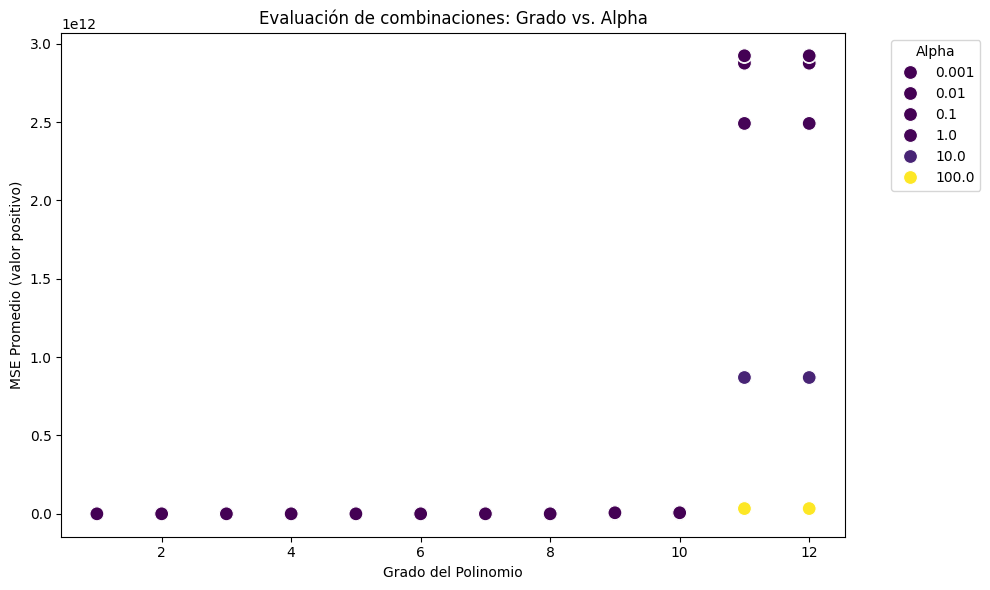

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# ---------------------------------------------------------
# 1. Preparación de los datos
# ---------------------------------------------------------
# Supongamos que 'cohort_revenue' es un DataFrame con índices tipo 'YYYY-MM'
# y queremos trabajar con la cohorte '2019-12'.
# Se aplica la transformación logarítmica (log1p para evitar problemas con ceros)
cohorte_2019_12_log = np.log1p(cohort_revenue.loc['2019-12'].dropna())

# Convertir los índices (meses) a fechas y crear un vector numérico para la regresión
X_dates = pd.to_datetime(cohorte_2019_12_log.index.astype(str), format='%Y-%m')
X_numeric = np.arange(len(X_dates)).reshape(-1, 1)
y = np.array(cohorte_2019_12_log.values)

# Usaremos el 80% de los datos (interpolación) para la selección de hiperparámetros.
split_idx = int(len(X_numeric) * 0.8)
X_interp = X_numeric[:split_idx]
y_interp = y[:split_idx]

# ---------------------------------------------------------
# 2. Definir el Pipeline con StandardScaler, PolynomialFeatures y Ridge
# ---------------------------------------------------------
pipeline = Pipeline([
    ('scaler', StandardScaler()),         # Escalado de la variable
    ('poly', PolynomialFeatures()),       # Expansión polinómica
    ('ridge', Ridge())                    # Regresión Ridge
])

# Definir el grid: grados del 1 al 12 y diferentes valores para alpha.
param_grid = {
    'poly__degree': list(range(1, 13)),
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# ---------------------------------------------------------
# 3. Configurar y ejecutar GridSearchCV con TimeSeriesSplit
# ---------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=3)  # Debido al poco número de puntos, usamos pocos splits
grid = GridSearchCV(pipeline, param_grid, cv=tscv,
                    scoring='neg_mean_squared_error',
                    return_train_score=True)
grid.fit(X_interp, y_interp)

# Convertir los resultados a DataFrame para visualizarlos fácilmente.
results = pd.DataFrame(grid.cv_results_)

# Seleccionar las columnas de interés.
cols_interes = ['param_poly__degree', 'param_ridge__alpha',
                'mean_test_score', 'std_test_score', 'rank_test_score']

# Ordenar según el ranking (el mejor score tendrá rank 1)
results_ordenados = results[cols_interes].sort_values(by='rank_test_score')

print("Todas las combinaciones evaluadas:")
print(results_ordenados)

# ---------------------------------------------------------
# 4. (Opcional) Visualización gráfica de la evolución de los puntajes
# ---------------------------------------------------------
# Convertir el score a positivo para interpretarlo como MSE
results_ordenados['mean_test_MSE'] = -results_ordenados['mean_test_score']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_ordenados,
                x='param_poly__degree',
                y='mean_test_MSE',
                hue='param_ridge__alpha',
                palette="viridis",
                s=100)
plt.xlabel("Grado del Polinomio")
plt.ylabel("MSE Promedio (valor positivo)")
plt.title("Evaluación de combinaciones: Grado vs. Alpha")
plt.legend(title='Alpha', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


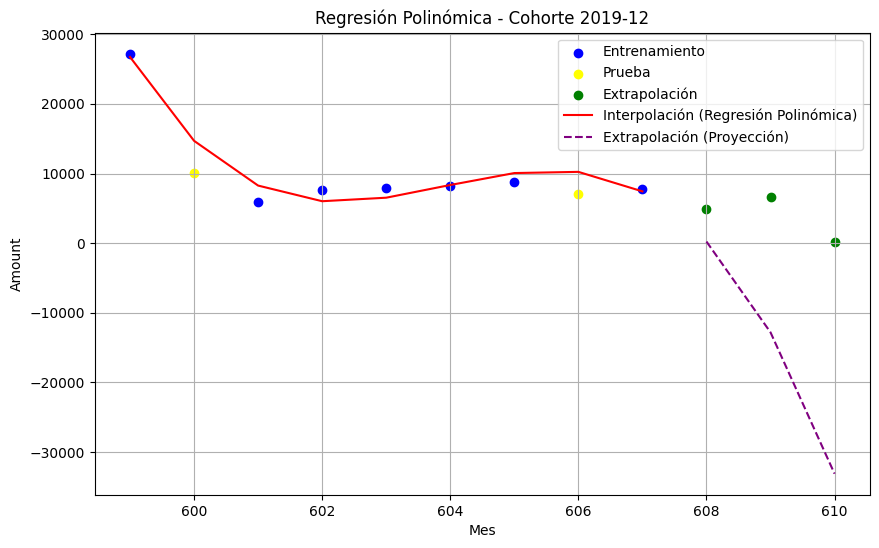

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Filtrar datos del cohorte 2019-12
cohorte_2019_12 = cohort_revenue.loc['2019-12'].dropna()

# Convertir índices (Mes) a enteros
X = np.array(cohorte_2019_12.index.astype(int)).reshape(-1, 1)  # Convertir a matriz 2D
y = np.array(cohorte_2019_12.values)  # Valores de amount

# Separar 80% interpolación y 20% extrapolación
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X[:split_idx], X[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# Dentro del 80% de interpolación, dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# Ajustar modelo de regresión polinómica de grado 3 (puedes cambiar el grado)
degree = 3
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_interp_poly = poly.transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# Entrenar modelo con datos de interpolación
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predicciones
y_interp_pred = model.predict(X_interp_poly)  # Predicciones en interpolación
y_extrap_pred = model.predict(X_extrap_poly)  # Predicciones en extrapolación

# Graficar resultados
plt.figure(figsize=(10, 6))

# Datos originales
plt.scatter(X_train, y_train, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test, color='yellow', label='Prueba')
plt.scatter(X_extrap, y_extrap, color='green', label='Extrapolación')

# Líneas de tendencia
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación (Regresión Polinómica)')
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación (Proyección)')

# Configuración de la gráfica
plt.xlabel("Mes")
plt.ylabel("Amount")
plt.title("Regresión Polinómica - Cohorte 2019-12")
plt.legend()
plt.grid(True)
plt.show()


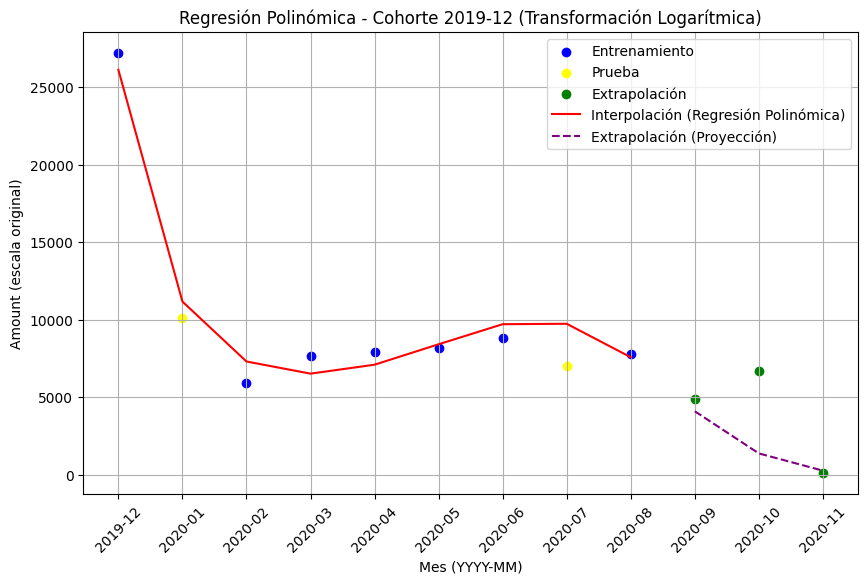

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1️⃣ Aplicar la transformación logarítmica en 'amount'
cohorte_2019_12_log = np.log1p(cohort_revenue.loc['2019-12'].dropna())

# 2️⃣ Convertir índices (Mes) a fechas tipo 'YYYY-MM'
X = pd.to_datetime(cohorte_2019_12_log.index.astype(str), format='%Y-%m')
X_numeric = np.array(range(len(X))).reshape(-1, 1)  # Convertir a índices numéricos para la regresión
y = np.array(cohorte_2019_12_log.values)  # Valores transformados

# 3️⃣ Separar 80% interpolación y 20% extrapolación
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X_numeric[:split_idx], X_numeric[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 4️⃣ Dentro del 80% de interpolación, dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 5️⃣ Ajustar modelo de regresión polinómica (Grado 3)
degree = 3
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_interp_poly = poly.transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# 6️⃣ Entrenar modelo con datos de interpolación
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 7️⃣ Predicciones
y_interp_pred = model.predict(X_interp_poly)  # Predicciones en interpolación
y_extrap_pred = model.predict(X_extrap_poly)  # Predicciones en extrapolación

# 8️⃣ Volver a la escala original (deshacer logaritmo)
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_extrap_orig = np.expm1(y_extrap)

# 9️⃣ Graficar resultados
plt.figure(figsize=(10, 6))

# Datos originales transformados de vuelta
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

# Líneas de tendencia
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación (Regresión Polinómica)')
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación (Proyección)')

#  🔄 Convertir los valores numéricos de X a etiquetas de fecha
plt.xticks(X_numeric.flatten(), X.strftime('%Y-%m'), rotation=45)

# Configuración de la gráfica
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title("Regresión Polinómica - Cohorte 2019-12 (Transformación Logarítmica)")
plt.legend()
plt.grid(True)
plt.show()


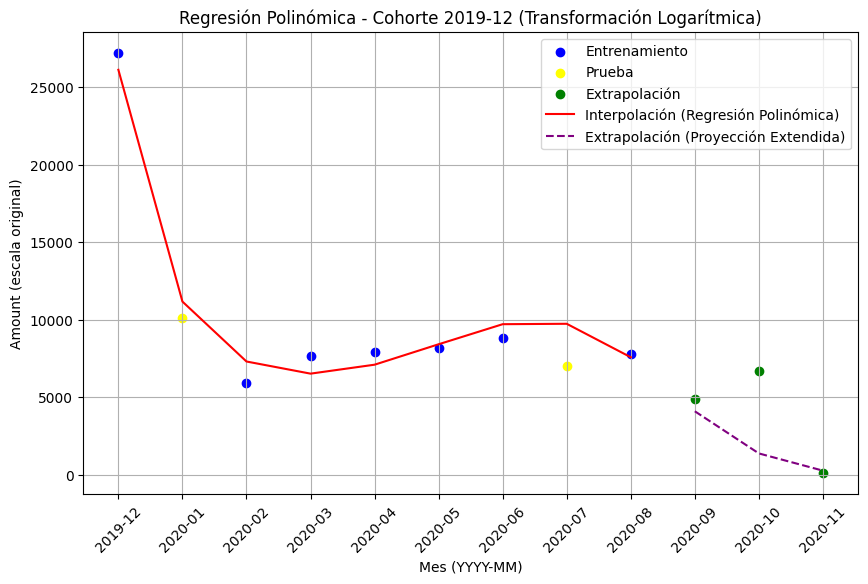

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1️⃣ Aplicar la transformación logarítmica en 'amount'
cohorte_2019_12_log = np.log1p(cohort_revenue.loc['2019-12'].dropna())

# 2️⃣ Convertir índices (Mes) a fechas tipo 'YYYY-MM'
X = pd.to_datetime(cohorte_2019_12_log.index.astype(str), format='%Y-%m')
X_numeric = np.array(range(len(X))).reshape(-1, 1)  # Convertir a índices numéricos para la regresión
y = np.array(cohorte_2019_12_log.values)  # Valores transformados

# 3️⃣ Separar 80% interpolación y 20% extrapolación
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X_numeric[:split_idx], X_numeric[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 4️⃣ Dentro del 80% de interpolación, dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 5️⃣ Ajustar modelo de regresión polinómica (Grado 3)
degree = 3
poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_interp_poly = poly.transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# 6️⃣ Entrenar modelo con datos de interpolación
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 7️⃣ Predicciones
y_interp_pred = model.predict(X_interp_poly)  # Predicciones en interpolación
y_extrap_pred = model.predict(X_extrap_poly)  # Predicciones en extrapolación

# 8️⃣ Volver a la escala original (deshacer logaritmo)
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_extrap_orig = np.expm1(y_extrap)

# 9️⃣ Graficar resultados
plt.figure(figsize=(10, 6))

# Datos originales transformados de vuelta
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

# Líneas de tendencia
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación (Regresión Polinómica)')
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación (Proyección Extendida)')

# 🔄 Convertir los valores numéricos de X a etiquetas de fecha
plt.xticks(X_numeric.flatten(), X.strftime('%Y-%m'), rotation=45)

# Configuración de la gráfica
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title("Regresión Polinómica - Cohorte 2019-12 (Transformación Logarítmica)")
plt.legend()
plt.grid(True)
plt.show()


📊 Resumen estadístico de y_interp:
count     9.000000
mean      9.103978
std       0.440943
min       8.679652
25%       8.942592
50%       8.974745
75%       9.083189
max      10.210899
dtype: float64

📊 Resumen estadístico de y_extrap:
count    3.000000
mean     7.302465
std      2.332607
min      4.615121
25%      6.552060
50%      8.488999
75%      8.646137
max      8.803274
dtype: float64

📈 Correlación entre los últimos 3 puntos de interpolación y primeros 3 de extrapolación:
[[ 1.         -0.03210959]
 [-0.03210959  1.        ]]

📊 Evaluación del Modelo:
RMSE Interpolación: 643.779, RMSE Extrapolación: 179365.703
R² Interpolación: 0.988, R² Extrapolación: -0.739

🔍 Valores negativos en extrapolación:
[]


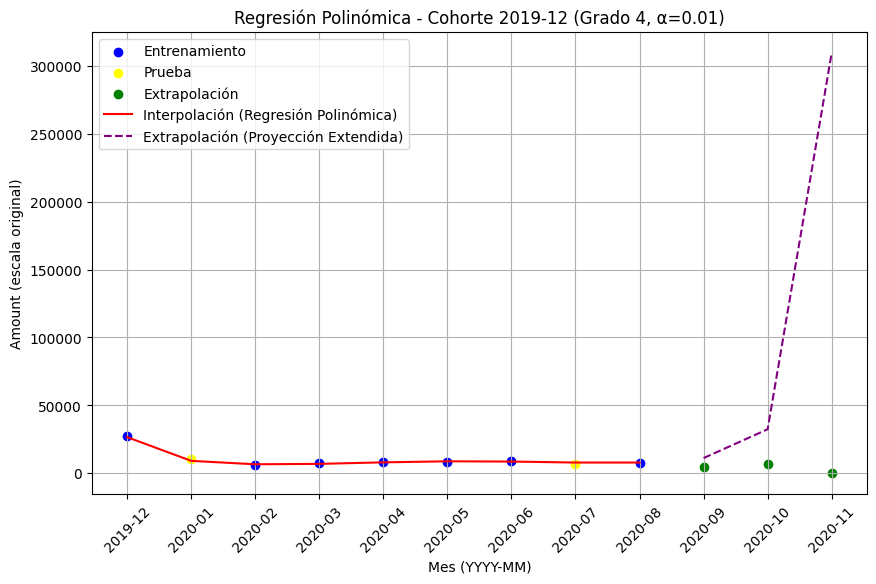

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1️⃣ Aplicar la transformación logarítmica en 'amount'
cohorte_2019_12_log = np.log1p(cohort_revenue.loc['2019-12'].dropna())

# 2️⃣ Convertir índices (Mes) a fechas tipo 'YYYY-MM'
X = pd.to_datetime(cohorte_2019_12_log.index.astype(str), format='%Y-%m')
X_numeric = np.array(range(len(X))).reshape(-1, 1)  # Convertir a índices numéricos para la regresión
y = np.array(cohorte_2019_12_log.values)  # Valores transformados

# 3️⃣ Separar 80% interpolación y 20% extrapolación
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X_numeric[:split_idx], X_numeric[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 4️⃣ Dentro del 80% de interpolación, dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 📊 Evaluación previa: Distribución de datos
print("📊 Resumen estadístico de y_interp:")
print(pd.Series(y_interp).describe())

print("\n📊 Resumen estadístico de y_extrap:")
print(pd.Series(y_extrap).describe())

# 📈 Correlación entre los últimos puntos de interpolación y primeros de extrapolación
print("\n📈 Correlación entre los últimos 3 puntos de interpolación y primeros 3 de extrapolación:")
print(np.corrcoef(y_interp[-3:], y_extrap[:3]))

# 5️⃣ Ajustar modelo de regresión polinómica con Ridge para evitar sobreajuste
degree = 4  # Se puede probar con otros grados
alpha = 0.01  # Regularización

poly = PolynomialFeatures(degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_interp_poly = poly.transform(X_interp)
X_extrap_poly = poly.transform(X_extrap)

# 6️⃣ Entrenar modelo con Ridge
model = Ridge(alpha=alpha)
model.fit(X_train_poly, y_train)

# 7️⃣ Predicciones
y_interp_pred = model.predict(X_interp_poly)  # Predicciones en interpolación
y_extrap_pred = model.predict(X_extrap_poly)  # Predicciones en extrapolación

# 8️⃣ Volver a la escala original (deshacer logaritmo)
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_extrap_orig = np.expm1(y_extrap)

# 9️⃣ Evaluación de modelo: RMSE y R²
rmse_interp = np.sqrt(mean_squared_error(y_interp_pred, np.expm1(y_interp)))
rmse_extrap = np.sqrt(mean_squared_error(y_extrap_pred, y_extrap_orig))
r2_interp = r2_score(y_interp_pred, np.expm1(y_interp))
r2_extrap = r2_score(y_extrap_pred, y_extrap_orig)

print(f"\n📊 Evaluación del Modelo:")
print(f"RMSE Interpolación: {rmse_interp:.3f}, RMSE Extrapolación: {rmse_extrap:.3f}")
print(f"R² Interpolación: {r2_interp:.3f}, R² Extrapolación: {r2_extrap:.3f}")

# 🔍 Ver si hay valores negativos en extrapolación (no deberían existir en Amount)
print("\n🔍 Valores negativos en extrapolación:")
print(y_extrap_pred[y_extrap_pred < 0])

#  🔄 Convertir los valores numéricos de X a etiquetas de fecha
plt.figure(figsize=(10, 6))

# Datos originales transformados de vuelta
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_test, y_test_orig, color='yellow', label='Prueba')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación')

# Líneas de tendencia
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label='Interpolación (Regresión Polinómica)')
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label='Extrapolación (Proyección Extendida)')

# Configuración de la gráfica
plt.xticks(X_numeric.flatten(), X.strftime('%Y-%m'), rotation=45)
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title(f"Regresión Polinómica - Cohorte 2019-12 (Grado {degree}, α={alpha})")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# 1️⃣ Función para probar múltiples combinaciones de modelos
def evaluate_models(X, y):
    best_model = None
    best_poly = None
    best_r2 = -np.inf
    best_rmse = np.inf
    best_config = None
    results = []

    degrees = list(range(2, 16))  # Grados del polinomio a probar (de 2 a 15)
    alphas = [0.1, 1, 10]  # Valores de alpha para Ridge y Lasso
    models = [
        ("Linear", LinearRegression(), None),
        ("Ridge", Ridge(), alphas),
        ("Lasso", Lasso(max_iter=10000), alphas),
    ]

    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    for degree in degrees:
        for model_name, model, alpha_values in models:
            if alpha_values is not None:
                for alpha in alpha_values:
                    poly = PolynomialFeatures(degree)
                    X_poly = poly.fit_transform(X)
                    model.set_params(alpha=alpha)

                    # Validación Cruzada
                    mse_scores = cross_val_score(model, X_poly, y, cv=kf, scoring='neg_mean_squared_error')
                    rmse = np.sqrt(-np.mean(mse_scores))

                    # Entrenar modelo final
                    model.fit(X_poly, y)
                    y_pred = model.predict(X_poly)
                    r2 = r2_score(y, y_pred)

                    # Guardar resultados
                    results.append((model_name, degree, alpha, r2, rmse))

                    # Actualizar el mejor modelo
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_r2 = r2
                        best_model = model
                        best_poly = poly
                        best_config = (model_name, degree, alpha)
            else:
                # Caso sin alpha (Regresión Lineal)
                poly = PolynomialFeatures(degree)
                X_poly = poly.fit_transform(X)

                mse_scores = cross_val_score(model, X_poly, y, cv=kf, scoring='neg_mean_squared_error')
                rmse = np.sqrt(-np.mean(mse_scores))

                model.fit(X_poly, y)
                y_pred = model.predict(X_poly)
                r2 = r2_score(y, y_pred)

                results.append((model_name, degree, None, r2, rmse))

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_r2 = r2
                    best_model = model
                    best_poly = poly
                    best_config = (model_name, degree, None)

    # Imprimir los resultados
    print("\n📊 Comparación de Modelos")
    for model_name, degree, alpha, r2, rmse in results:
        print(f"{model_name} (grado={degree}, alpha={alpha}): R²={r2:.4f}, RMSE={rmse:.4f}")

    print(f"\n🏆 Mejor modelo encontrado: {best_config} con RMSE={best_rmse:.4f} y R²={best_r2:.4f}")

    return best_model, best_poly, best_r2, best_rmse, best_config

# 2️⃣ Eliminar la columna '2020-11' si aún existe
if '2020-11' in cohort_revenue.columns:
    cohort_revenue = cohort_revenue.drop(columns=['2020-11'])

# 3️⃣ Aplicar la transformación logarítmica en 'amount' para la cohorte 2019-12
cohorte_2019_12_log = np.log1p(cohort_revenue.loc['2019-12'].dropna())

# 4️⃣ Convertir índices (Mes) a fechas tipo 'YYYY-MM'
X = pd.to_datetime(cohorte_2019_12_log.index.astype(str), format='%Y-%m')
X_numeric = np.array(range(len(X))).reshape(-1, 1)  # Convertir a índices numéricos para la regresión
y = np.array(cohorte_2019_12_log.values)  # Valores transformados

# 5️⃣ Separar 80% interpolación y 20% extrapolación
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X_numeric[:split_idx], X_numeric[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 6️⃣ Dentro del 80% de interpolación, dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 7️⃣ Evaluar todos los modelos
best_model, best_poly, best_r2, best_rmse, best_config = evaluate_models(X_train, y_train)

# 8️⃣ Transformar datos con la mejor configuración
X_train_poly = best_poly.transform(X_train)
X_test_poly = best_poly.transform(X_test)
X_interp_poly = best_poly.transform(X_interp)
X_extrap_poly = best_poly.transform(X_extrap)

# 9️⃣ Entrenar el mejor modelo encontrado
best_model.fit(X_train_poly, y_train)

# 🔟 Predicciones
y_interp_pred = best_model.predict(X_interp_poly)  # Predicciones en interpolación
y_extrap_pred = best_model.predict(X_extrap_poly)  # Predicciones en extrapolación

# 🔹 Volver a la escala original (deshacer logaritmo)
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_extrap_orig = np.expm1(y_extrap)




/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.988e-04, tolerance: 8.790e-06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.809e-02, tolerance: 1.252e-04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.035e-01, tolerance: 1.427e


📊 Comparación de Modelos
Linear (grado=2, alpha=None): R²=0.7286, RMSE=0.9397
Ridge (grado=2, alpha=0.1): R²=0.7278, RMSE=0.8538
Ridge (grado=2, alpha=1): R²=0.6868, RMSE=0.7248
Ridge (grado=2, alpha=10): R²=0.3717, RMSE=0.7255
Lasso (grado=2, alpha=0.1): R²=0.6183, RMSE=0.6895
Lasso (grado=2, alpha=1): R²=0.1361, RMSE=0.6788
Lasso (grado=2, alpha=10): R²=0.0000, RMSE=0.5973
Linear (grado=3, alpha=None): R²=0.9675, RMSE=1.4661
Ridge (grado=3, alpha=0.1): R²=0.9493, RMSE=0.7828
Ridge (grado=3, alpha=1): R²=0.7021, RMSE=0.8017
Ridge (grado=3, alpha=10): R²=0.4423, RMSE=0.7576
Lasso (grado=3, alpha=0.1): R²=0.5921, RMSE=0.7593
Lasso (grado=3, alpha=1): R²=0.0980, RMSE=0.7188
Lasso (grado=3, alpha=10): R²=0.0736, RMSE=0.6435
Linear (grado=4, alpha=None): R²=0.9880, RMSE=1.1670
Ridge (grado=4, alpha=0.1): R²=0.9289, RMSE=0.9604
Ridge (grado=4, alpha=1): R²=0.8267, RMSE=0.7993
Ridge (grado=4, alpha=10): R²=0.5701, RMSE=0.8271
Lasso (grado=4, alpha=0.1): R²=0.7661, RMSE=0.8004
Lasso (grado=4

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.634e-01, tolerance: 1.509e-04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singula

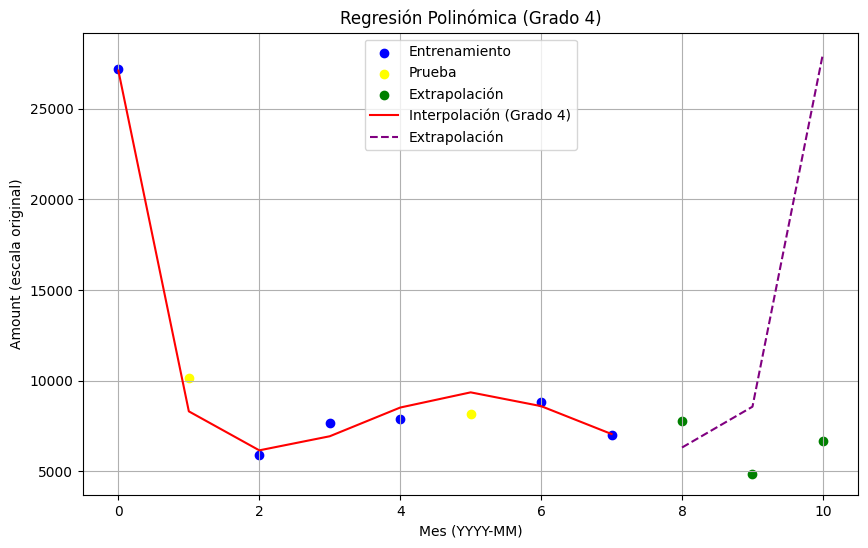

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Crear polinomio de grado 4
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Entrenar modelo Linear
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predicciones
y_interp_pred = model.predict(poly.transform(X_interp))
y_extrap_pred = model.predict(poly.transform(X_extrap))

# Volver a escala original
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)

# Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X_train, np.expm1(y_train), color='blue', label='Entrenamiento')
plt.scatter(X_test, np.expm1(y_test), color='yellow', label='Prueba')
plt.scatter(X_extrap, np.expm1(y_extrap), color='green', label='Extrapolación')
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación (Grado 4)")
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Extrapolación")
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title("Regresión Polinómica (Grado 4)")
plt.legend()
plt.grid(True)
plt.show()


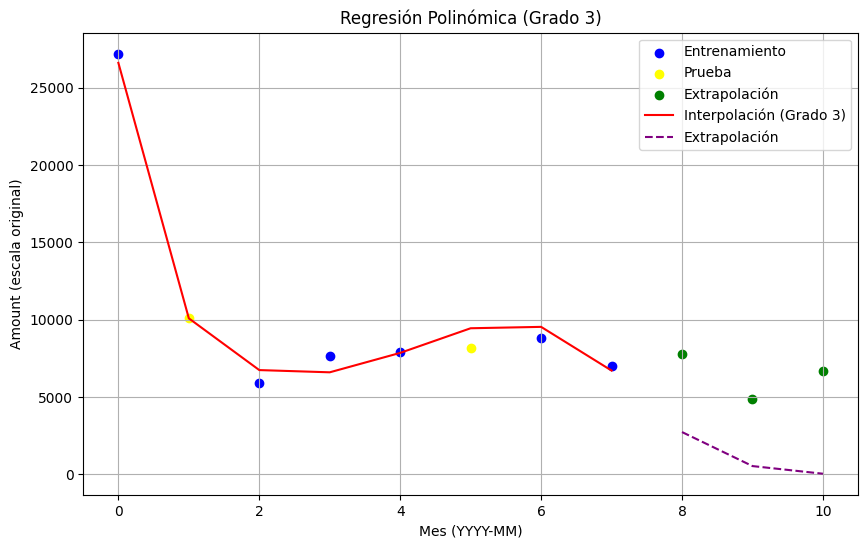

In [21]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_interp_pred = model.predict(poly.transform(X_interp))
y_extrap_pred = model.predict(poly.transform(X_extrap))

y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, np.expm1(y_train), color='blue', label='Entrenamiento')
plt.scatter(X_test, np.expm1(y_test), color='yellow', label='Prueba')
plt.scatter(X_extrap, np.expm1(y_extrap), color='green', label='Extrapolación')
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación (Grado 3)")
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Extrapolación")
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title("Regresión Polinómica (Grado 3)")
plt.legend()
plt.grid(True)
plt.show()


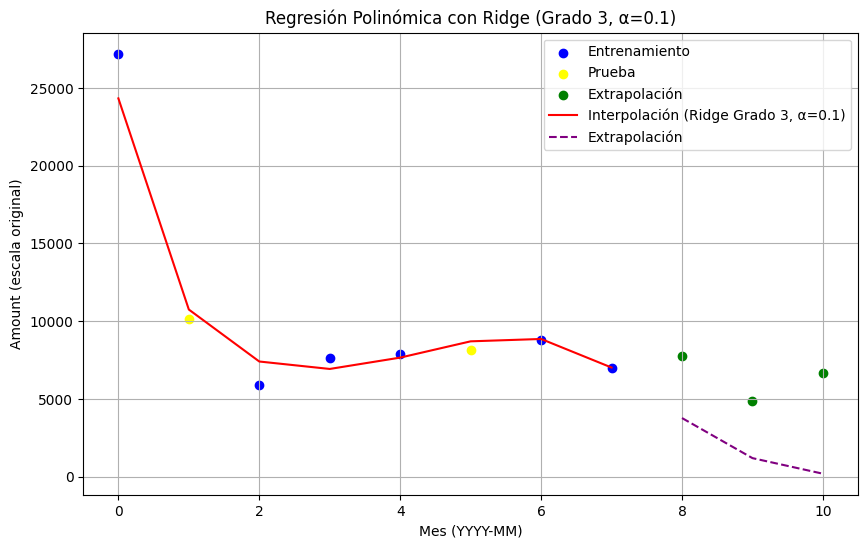

In [22]:
from sklearn.linear_model import Ridge

poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = Ridge(alpha=0.1)
model.fit(X_train_poly, y_train)

y_interp_pred = model.predict(poly.transform(X_interp))
y_extrap_pred = model.predict(poly.transform(X_extrap))

y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, np.expm1(y_train), color='blue', label='Entrenamiento')
plt.scatter(X_test, np.expm1(y_test), color='yellow', label='Prueba')
plt.scatter(X_extrap, np.expm1(y_extrap), color='green', label='Extrapolación')
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación (Ridge Grado 3, α=0.1)")
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Extrapolación")
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title("Regresión Polinómica con Ridge (Grado 3, α=0.1)")
plt.legend()
plt.grid(True)
plt.show()


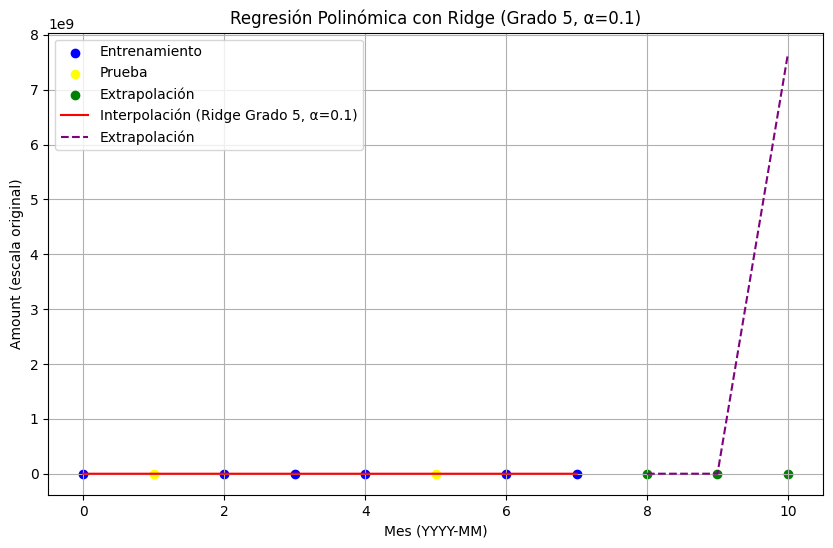

In [23]:
poly = PolynomialFeatures(degree=5)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = Ridge(alpha=0.1)
model.fit(X_train_poly, y_train)

y_interp_pred = model.predict(poly.transform(X_interp))
y_extrap_pred = model.predict(poly.transform(X_extrap))

y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, np.expm1(y_train), color='blue', label='Entrenamiento')
plt.scatter(X_test, np.expm1(y_test), color='yellow', label='Prueba')
plt.scatter(X_extrap, np.expm1(y_extrap), color='green', label='Extrapolación')
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación (Ridge Grado 5, α=0.1)")
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Extrapolación")
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title("Regresión Polinómica con Ridge (Grado 5, α=0.1)")
plt.legend()
plt.grid(True)
plt.show()


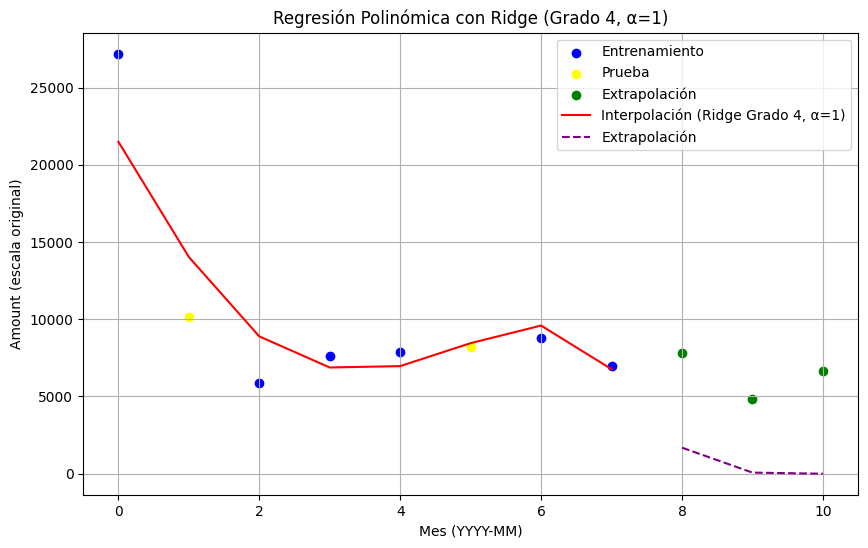

In [24]:
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = Ridge(alpha=1)
model.fit(X_train_poly, y_train)

y_interp_pred = model.predict(poly.transform(X_interp))
y_extrap_pred = model.predict(poly.transform(X_extrap))

y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, np.expm1(y_train), color='blue', label='Entrenamiento')
plt.scatter(X_test, np.expm1(y_test), color='yellow', label='Prueba')
plt.scatter(X_extrap, np.expm1(y_extrap), color='green', label='Extrapolación')
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación (Ridge Grado 4, α=1)")
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Extrapolación")
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title("Regresión Polinómica con Ridge (Grado 4, α=1)")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.988e-04, tolerance: 8.790e-06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.809e-02, tolerance: 1.252e-04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.035e-01, tolerance: 1.427e


📊 Comparación de Modelos (Interpolación y Extrapolación)
Lasso (grado=3, alpha=10): RMSE Interpolación=0.6435, RMSE Extrapolación=0.2029, RMSE Combinado=0.4232
Lasso (grado=2, alpha=1): RMSE Interpolación=0.6788, RMSE Extrapolación=0.2249, RMSE Combinado=0.4519
Ridge (grado=2, alpha=10): RMSE Interpolación=0.7255, RMSE Extrapolación=0.1861, RMSE Combinado=0.4558
Lasso (grado=2, alpha=10): RMSE Interpolación=0.5973, RMSE Extrapolación=0.4213, RMSE Combinado=0.5093
Lasso (grado=3, alpha=1): RMSE Interpolación=0.7188, RMSE Extrapolación=0.4580, RMSE Combinado=0.5884
Lasso (grado=6, alpha=10): RMSE Interpolación=1.0295, RMSE Extrapolación=0.1737, RMSE Combinado=0.6016
Lasso (grado=2, alpha=0.1): RMSE Interpolación=0.6895, RMSE Extrapolación=0.5875, RMSE Combinado=0.6385
Lasso (grado=4, alpha=10): RMSE Interpolación=0.6997, RMSE Extrapolación=0.6531, RMSE Combinado=0.6764
Ridge (grado=3, alpha=1): RMSE Interpolación=0.8017, RMSE Extrapolación=0.6506, RMSE Combinado=0.7262
Lasso (grado=4, a

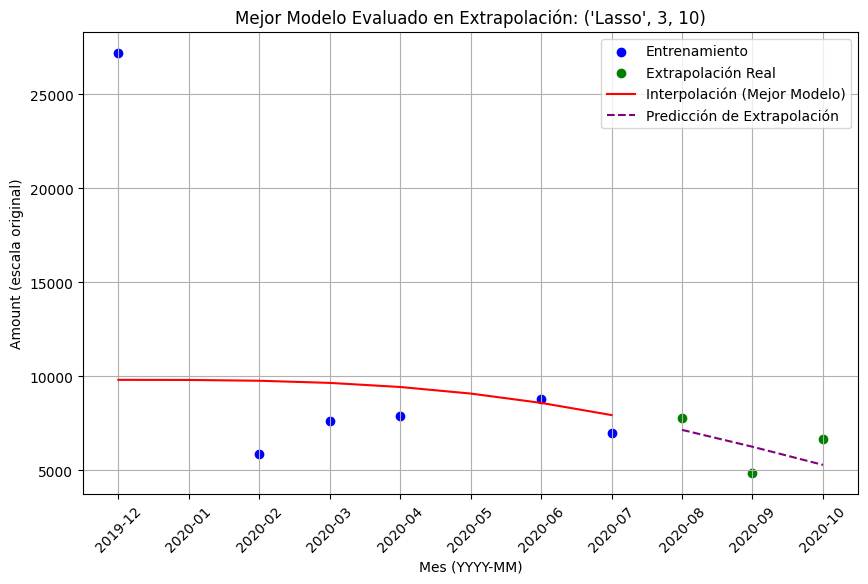

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# 1️⃣ Función para probar múltiples combinaciones de modelos
def evaluate_models(X_train, y_train, X_extrap, y_extrap):
    best_model = None
    best_poly = None
    best_combined_rmse = np.inf
    best_config = None
    results = []

    degrees = list(range(2, 16))  # Grados del polinomio a probar (de 2 a 15)
    alphas = [0.1, 1, 10]  # Valores de alpha para Ridge y Lasso
    models = [
        ("Linear", LinearRegression(), None),
        ("Ridge", Ridge(), alphas),
        ("Lasso", Lasso(max_iter=10000), alphas),
    ]

    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    for degree in degrees:
        for model_name, model, alpha_values in models:
            if alpha_values is not None:
                for alpha in alpha_values:
                    poly = PolynomialFeatures(degree)
                    X_train_poly = poly.fit_transform(X_train)
                    X_extrap_poly = poly.transform(X_extrap)

                    model.set_params(alpha=alpha)

                    # Validación Cruzada en Interpolación
                    mse_scores = cross_val_score(model, X_train_poly, y_train, cv=kf, scoring='neg_mean_squared_error')
                    interp_rmse = np.sqrt(-np.mean(mse_scores))

                    # Entrenar modelo con interpolación y evaluar extrapolación
                    model.fit(X_train_poly, y_train)
                    y_extrap_pred = model.predict(X_extrap_poly)
                    extrap_rmse = np.sqrt(mean_squared_error(y_extrap, y_extrap_pred))

                    # Calcular RMSE combinado (Interpolación + Extrapolación)
                    combined_rmse = (interp_rmse + extrap_rmse) / 2

                    results.append((model_name, degree, alpha, interp_rmse, extrap_rmse, combined_rmse))

                    # Seleccionar el mejor modelo con menor RMSE combinado
                    if combined_rmse < best_combined_rmse:
                        best_combined_rmse = combined_rmse
                        best_model = model
                        best_poly = poly
                        best_config = (model_name, degree, alpha)

            else:
                # Caso sin alpha (Regresión Lineal)
                poly = PolynomialFeatures(degree)
                X_train_poly = poly.fit_transform(X_train)
                X_extrap_poly = poly.transform(X_extrap)

                mse_scores = cross_val_score(model, X_train_poly, y_train, cv=kf, scoring='neg_mean_squared_error')
                interp_rmse = np.sqrt(-np.mean(mse_scores))

                model.fit(X_train_poly, y_train)
                y_extrap_pred = model.predict(X_extrap_poly)
                extrap_rmse = np.sqrt(mean_squared_error(y_extrap, y_extrap_pred))

                combined_rmse = (interp_rmse + extrap_rmse) / 2

                results.append((model_name, degree, None, interp_rmse, extrap_rmse, combined_rmse))

                if combined_rmse < best_combined_rmse:
                    best_combined_rmse = combined_rmse
                    best_model = model
                    best_poly = poly
                    best_config = (model_name, degree, None)

    # Imprimir los resultados
    print("\n📊 Comparación de Modelos (Interpolación y Extrapolación)")
    for model_name, degree, alpha, interp_rmse, extrap_rmse, combined_rmse in sorted(results, key=lambda x: x[-1]):
        print(f"{model_name} (grado={degree}, alpha={alpha}): "
              f"RMSE Interpolación={interp_rmse:.4f}, RMSE Extrapolación={extrap_rmse:.4f}, "
              f"RMSE Combinado={combined_rmse:.4f}")

    print(f"\n🏆 Mejor modelo encontrado: {best_config} con RMSE combinado={best_combined_rmse:.4f}")

    return best_model, best_poly, best_config

# 2️⃣ Eliminar la columna '2020-11' si aún existe
if '2020-11' in cohort_revenue.columns:
    cohort_revenue = cohort_revenue.drop(columns=['2020-11'])

# 3️⃣ Aplicar la transformación logarítmica en 'amount' para la cohorte 2019-12
cohorte_2019_12_log = np.log1p(cohort_revenue.loc['2019-12'].dropna())

# 4️⃣ Convertir índices (Mes) a fechas tipo 'YYYY-MM'
X = pd.to_datetime(cohorte_2019_12_log.index.astype(str), format='%Y-%m')
X_numeric = np.array(range(len(X))).reshape(-1, 1)  # Convertir a índices numéricos para la regresión
y = np.array(cohorte_2019_12_log.values)  # Valores transformados

# 5️⃣ Separar 80% interpolación y 20% extrapolación
split_idx = int(len(X) * 0.8)
X_interp, X_extrap = X_numeric[:split_idx], X_numeric[split_idx:]
y_interp, y_extrap = y[:split_idx], y[split_idx:]

# 6️⃣ Dentro del 80% de interpolación, dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# 7️⃣ Evaluar todos los modelos con Interpolación y Extrapolación
best_model, best_poly, best_config = evaluate_models(X_train, y_train, X_extrap, y_extrap)

# 8️⃣ Transformar datos con la mejor configuración
X_train_poly = best_poly.transform(X_train)
X_test_poly = best_poly.transform(X_test)
X_interp_poly = best_poly.transform(X_interp)
X_extrap_poly = best_poly.transform(X_extrap)

# 9️⃣ Entrenar el mejor modelo encontrado
best_model.fit(X_train_poly, y_train)

# 🔟 Predicciones
y_interp_pred = best_model.predict(X_interp_poly)
y_extrap_pred = best_model.predict(X_extrap_poly)

# 🔹 Volver a la escala original (deshacer logaritmo)
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)
y_train_orig = np.expm1(y_train)
y_extrap_orig = np.expm1(y_extrap)

# 🔹 Graficar resultados
plt.figure(figsize=(10, 6))

# Datos originales transformados de vuelta
plt.scatter(X_train, y_train_orig, color='blue', label='Entrenamiento')
plt.scatter(X_extrap, y_extrap_orig, color='green', label='Extrapolación Real')
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación (Mejor Modelo)")
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Predicción de Extrapolación")

# 🔄 Convertir los valores numéricos de X a etiquetas de fecha
plt.xticks(X_numeric.flatten(), X.strftime('%Y-%m'), rotation=45)

# Configuración de la gráfica
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title(f"Mejor Modelo Evaluado en Extrapolación: {best_config}")
plt.legend()
plt.grid(True)
plt.show()


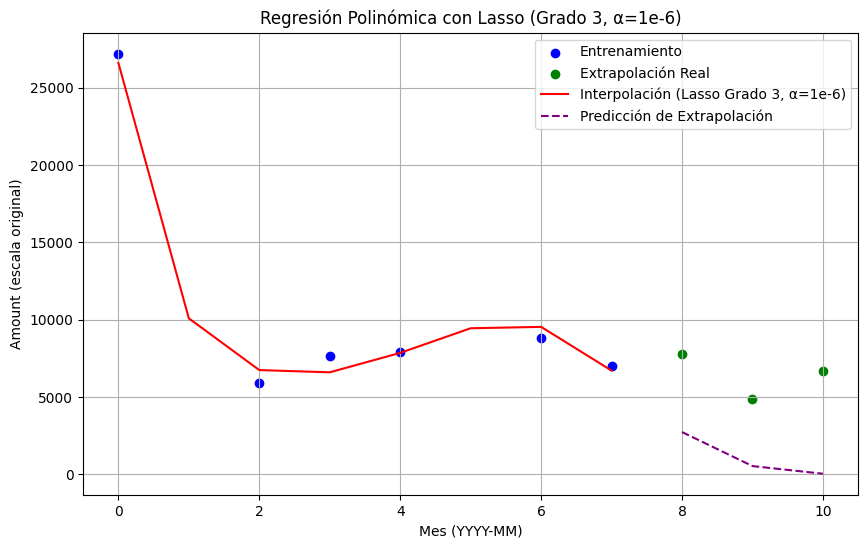

In [26]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures

# Crear polinomio de grado 3
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_extrap_poly = poly.transform(X_extrap)

# Entrenar modelo Lasso con regularización mínima
model = Lasso(alpha=1e-6, max_iter=100000)
model.fit(X_train_poly, y_train)

# Predicciones
y_interp_pred = model.predict(poly.transform(X_interp))
y_extrap_pred = model.predict(X_extrap_poly)

# Volver a escala original
y_interp_pred = np.expm1(y_interp_pred)
y_extrap_pred = np.expm1(y_extrap_pred)

# Graficar
plt.figure(figsize=(10, 6))
plt.scatter(X_train, np.expm1(y_train), color='blue', label='Entrenamiento')
plt.scatter(X_extrap, np.expm1(y_extrap), color='green', label='Extrapolación Real')
plt.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación (Lasso Grado 3, α=1e-6)")
plt.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Predicción de Extrapolación")
plt.xlabel("Mes (YYYY-MM)")
plt.ylabel("Amount (escala original)")
plt.title("Regresión Polinómica con Lasso (Grado 3, α=1e-6)")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.924e-03, tolerance: 1.509e-04
  model = cd_fast.enet_coordinate_descent(


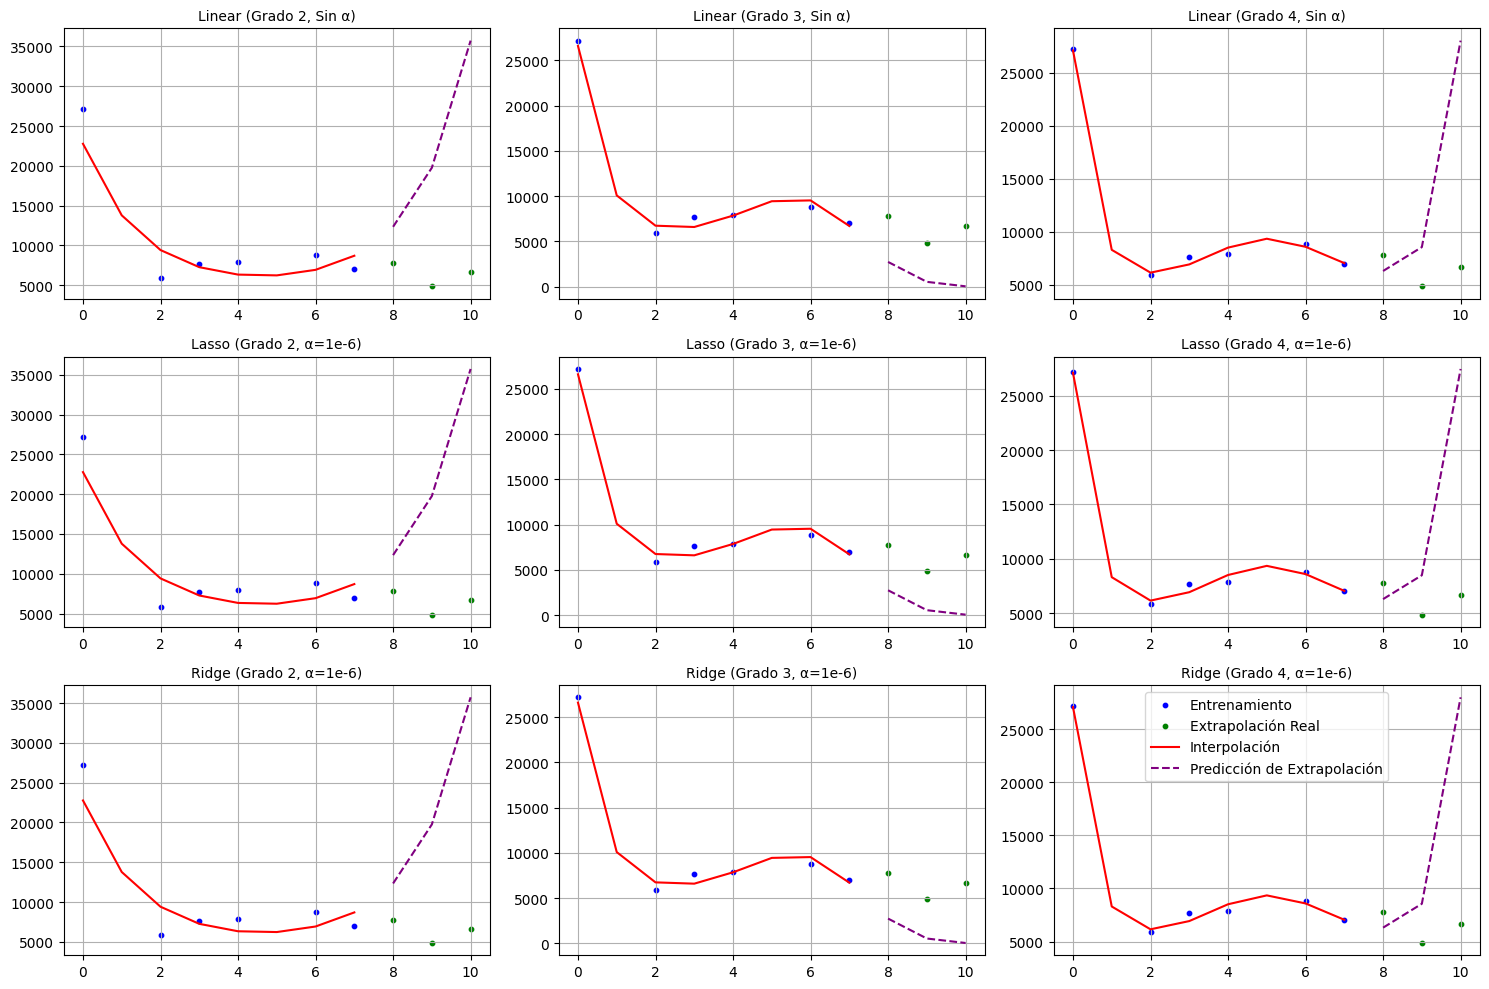

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# 🔹 Lista de modelos a probar
model_configs = [
    ("Linear", LinearRegression(), None, 2),
    ("Linear", LinearRegression(), None, 3),
    ("Linear", LinearRegression(), None, 4),
    ("Lasso", Lasso(alpha=1e-6, max_iter=100000), "α=1e-6", 2),
    ("Lasso", Lasso(alpha=1e-6, max_iter=100000), "α=1e-6", 3),
    ("Lasso", Lasso(alpha=1e-6, max_iter=100000), "α=1e-6", 4),
    ("Ridge", Ridge(alpha=1e-6), "α=1e-6", 2),
    ("Ridge", Ridge(alpha=1e-6), "α=1e-6", 3),
    ("Ridge", Ridge(alpha=1e-6), "α=1e-6", 4),
]

# 🔹 Crear subgráficos para visualizar todos los modelos
fig, axes = plt.subplots(len(model_configs) // 3, 3, figsize=(15, 10))  # 3 columnas
axes = axes.flatten()  # Asegurar que sea un array plano

for i, (name, model, alpha, degree) in enumerate(model_configs):
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_extrap_poly = poly.transform(X_extrap)

    model.fit(X_train_poly, y_train)

    y_interp_pred = model.predict(poly.transform(X_interp))
    y_extrap_pred = model.predict(X_extrap_poly)

    # Volver a escala original
    y_interp_pred = np.expm1(y_interp_pred)
    y_extrap_pred = np.expm1(y_extrap_pred)

    # 🔹 Gráfico individual en cada subplot
    ax = axes[i]
    ax.scatter(X_train, np.expm1(y_train), color='blue', label='Entrenamiento', s=10)
    ax.scatter(X_extrap, np.expm1(y_extrap), color='green', label="Extrapolación Real", s=10)
    ax.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación")
    ax.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Predicción de Extrapolación")
    ax.set_title(f"{name} (Grado {degree}, {alpha if alpha else 'Sin α'})", fontsize=10)
    ax.grid(True)

plt.tight_layout()
plt.legend()
plt.show()


IndexError: index 20 is out of bounds for axis 0 with size 20

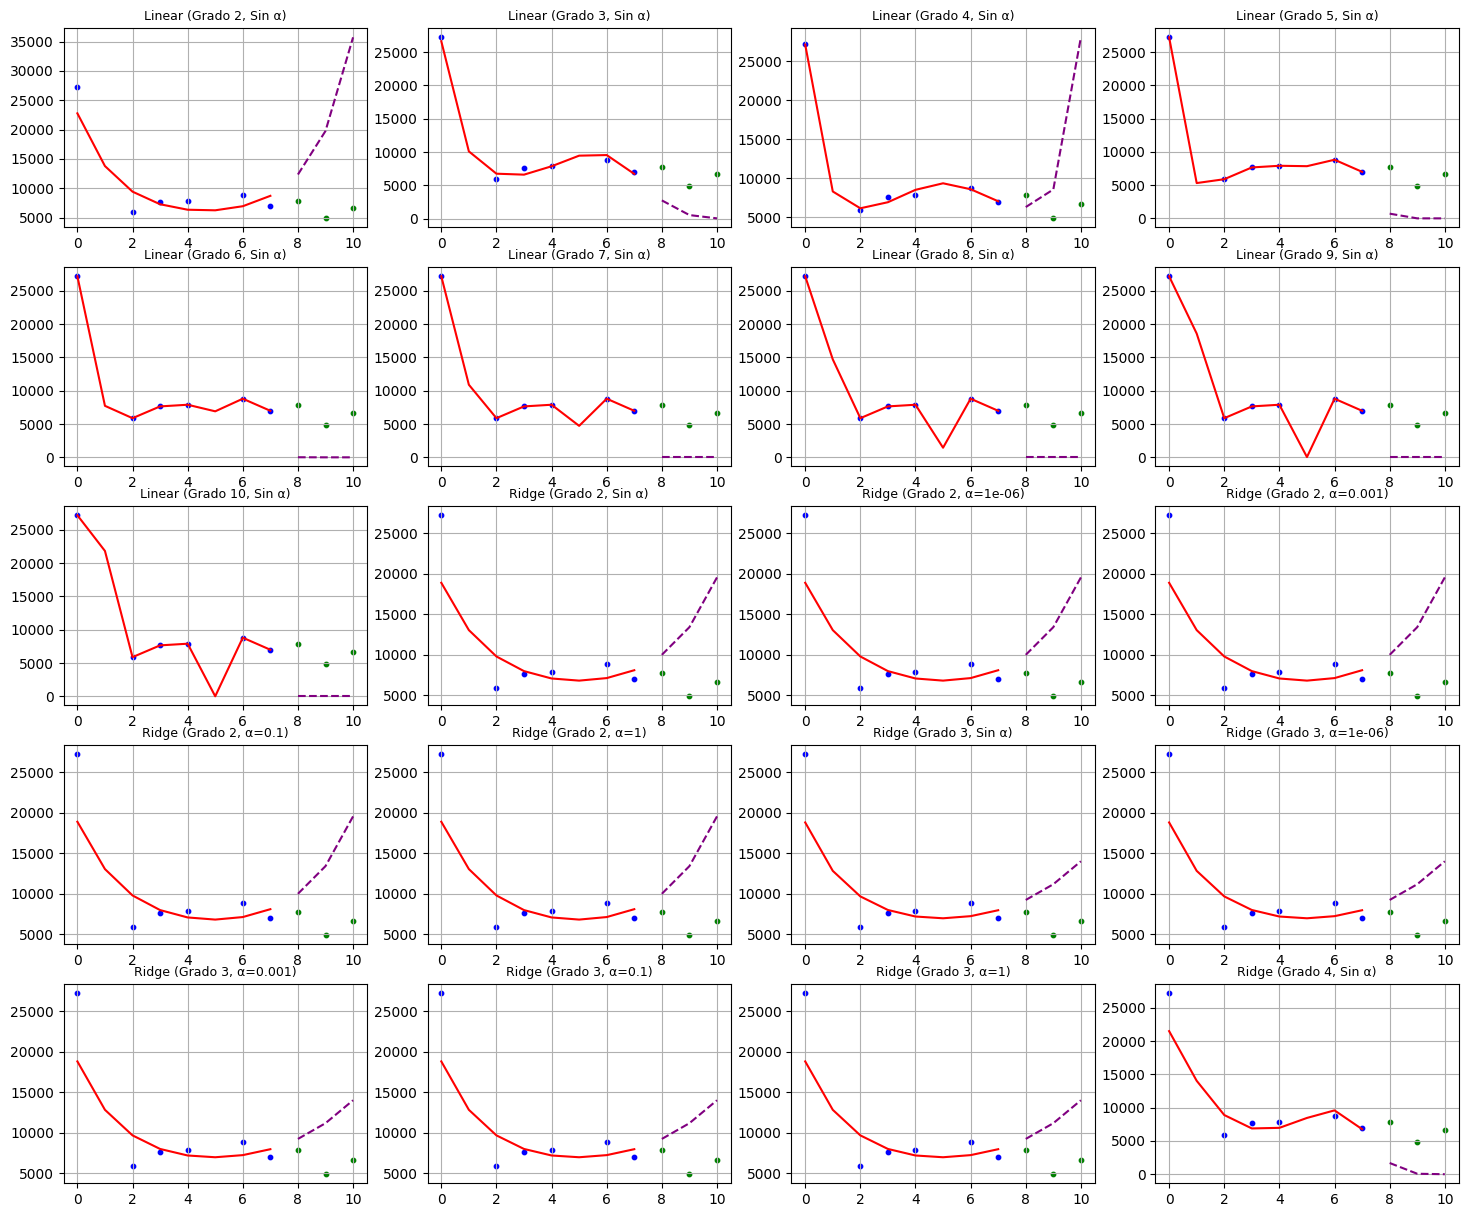

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# 🔹 Definir combinaciones de modelos, grados y regularizaciones
degrees = range(2, 11)  # Ahora incluimos polinomios de grado 2 hasta 10
alphas = [None, 1e-6, 1e-3, 0.1, 1]  # Diferentes niveles de regularización
models = [
    ("Linear", LinearRegression(), None),
    ("Ridge", Ridge(), alphas),
    ("Lasso", Lasso(max_iter=10000), alphas),
]

# 🔹 Crear todas las combinaciones posibles
model_configs = []
for name, model, alpha_values in models:
    for degree in degrees:
        if alpha_values is None:  # Modelos sin alpha (Linear)
            model_configs.append((name, model, None, degree))
        else:  # Modelos con alpha (Ridge y Lasso)
            for alpha in alpha_values:
                model_configs.append((name, model.set_params(alpha=alpha), alpha, degree))

# 🔹 Elegir solo algunas combinaciones para graficar (máximo 20 gráficos)
selected_configs = model_configs[:50]

# 🔹 Configurar los subgráficos
fig, axes = plt.subplots(5, 4, figsize=(18, 15))  # 5 filas, 4 columnas
axes = axes.flatten()  # Asegurar que los subgráficos sean un array plano

for i, (name, model, alpha, degree) in enumerate(selected_configs):
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_extrap_poly = poly.transform(X_extrap)

    model.fit(X_train_poly, y_train)

    y_interp_pred = model.predict(poly.transform(X_interp))
    y_extrap_pred = model.predict(X_extrap_poly)

    # Volver a la escala original
    y_interp_pred = np.expm1(y_interp_pred)
    y_extrap_pred = np.expm1(y_extrap_pred)

    # 🔹 Graficar en cada subplot
    ax = axes[i]
    ax.scatter(X_train, np.expm1(y_train), color='blue', label='Entrenamiento', s=10)
    ax.scatter(X_extrap, np.expm1(y_extrap), color='green', label="Extrapolación Real", s=10)
    ax.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación")
    ax.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Predicción de Extrapolación")
    ax.set_title(f"{name} (Grado {degree}, {f'α={alpha}' if alpha is not None else 'Sin α'})", fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# 🔹 Definir valores de regularización para Ridge
alphas = [1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 0.1, 1, 10]  # Más opciones de α
degree = 4  # Nos enfocamos en el polinomio de grado 4

# 🔹 Configurar los subgráficos
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # 2 filas, 4 columnas
axes = axes.flatten()

for i, alpha in enumerate(alphas):
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_extrap_poly = poly.transform(X_extrap)

    # Entrenar Ridge con la regularización seleccionada
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)

    y_interp_pred = model.predict(poly.transform(X_interp))
    y_extrap_pred = model.predict(X_extrap_poly)

    # Volver a la escala original
    y_interp_pred = np.expm1(y_interp_pred)
    y_extrap_pred = np.expm1(y_extrap_pred)

    # 🔹 Graficar cada modelo
    ax = axes[i]
    ax.scatter(X_train, np.expm1(y_train), color='blue', label='Entrenamiento', s=10)
    ax.scatter(X_extrap, np.expm1(y_extrap), color='green', label="Extrapolación Real", s=10)
    ax.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación")
    ax.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Predicción de Extrapolación")
    ax.set_title(f"Ridge (Grado 4, α={alpha})", fontsize=10)
    ax.grid(True)

plt.tight_layout()
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 Valores de alpha más detallados en torno a 0.01
alphas = [0.005, 0.0075, 0.01, 0.015, 0.02]
degree = 4  # Fijamos el polinomio de grado 4

# 🔹 Configurar los subgráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # 2 filas, 3 columnas
axes = axes.flatten()

best_model = None
best_rmse = float('inf')

for i, alpha in enumerate(alphas):
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_extrap_poly = poly.transform(X_extrap)

    # Entrenar modelo Ridge con el alpha actual
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)

    # Predicciones en interpolación y extrapolación
    y_interp_pred = model.predict(poly.transform(X_interp))
    y_extrap_pred = model.predict(X_extrap_poly)

    # Volver a la escala original
    y_interp_pred = np.expm1(y_interp_pred)
    y_extrap_pred = np.expm1(y_extrap_pred)

    # 🔹 Validación Cruzada K-Fold
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_poly, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    avg_rmse = -np.mean(cv_scores)

    # Calcular R² y RMSE en datos de prueba
    r2_interp = r2_score(np.expm1(y_interp), y_interp_pred)
    rmse_interp = np.sqrt(mean_squared_error(np.expm1(y_interp), y_interp_pred))

    r2_extrap = r2_score(np.expm1(y_extrap), y_extrap_pred)
    rmse_extrap = np.sqrt(mean_squared_error(np.expm1(y_extrap), y_extrap_pred))

    combined_rmse = (rmse_interp + rmse_extrap) / 2

    # Guardar el mejor modelo
    if combined_rmse < best_rmse:
        best_rmse = combined_rmse
        best_model = (alpha, model, poly)

    # 🔹 Graficar el modelo actual
    ax = axes[i]
    ax.scatter(X_train, np.expm1(y_train), color='blue', label='Entrenamiento', s=10)
    ax.scatter(X_extrap, np.expm1(y_extrap), color='green', label="Extrapolación Real", s=10)
    ax.plot(X_interp, y_interp_pred, color='red', linestyle='-', label="Interpolación")
    ax.plot(X_extrap, y_extrap_pred, color='purple', linestyle='--', label="Predicción de Extrapolación")
    ax.set_title(f"Ridge (Grado 4, α={alpha})\nRMSE Int: {rmse_interp:.3f}, RMSE Ext: {rmse_extrap:.3f}", fontsize=10)
    ax.grid(True)

plt.tight_layout()
plt.legend()
plt.show()

# 🔹 Mostrar el mejor modelo
best_alpha, best_ridge, best_poly = best_model
print(f"✅ Mejor modelo: Ridge (Grado 4, α={best_alpha}) con RMSE combinado: {best_rmse:.3f}")
